# 03. Counterfactual Analysis

## 📚 Learning Objectives

By completing this notebook, you will:
- Generate and use counterfactual explanations
- Support recourse and understanding of decisions
- Assess counterfactual quality and constraints

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

---

# 03. Counterfactual Analysis

## 🚨 THE PROBLEM: We Need "What If" Explanations

**Remember the limitation from the previous notebook?**

We learned LIME for fast, local explanations. But we discovered:

**What if we need to understand what would change a prediction?**

**The Problem**: Sometimes we need:
- ❌ **"What if" scenarios** (what would change the outcome?)
- ❌ **Actionable explanations** (what should I change to get a different result?)
- ❌ **Counterfactual reasoning** (if X had been different, then Y would be different)
- ❌ **Decision guidance** (how to achieve desired outcomes)

**We've learned:**
- ✅ How to use SHAP for explanations (Notebook 1)
- ✅ How to use LIME for fast explanations (Notebook 2)
- ✅ Feature importance and local explanations

**But we haven't learned:**
- ❌ How to generate **counterfactual examples**
- ❌ How to answer **"what if" questions**
- ❌ How to provide **actionable guidance**
- ❌ How to show **what needs to change** for different outcomes

**We need counterfactual analysis** to:
1. Generate "what if" scenarios
2. Show what would change a prediction
3. Provide actionable guidance
4. Enable decision-making support

**This notebook solves that problem** by teaching you counterfactual analysis for "what if" explanations!

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: SHAP Explanations** - Understanding explainability
- ✅ **Example 2: LIME Explanations** - Understanding local explanations
- ✅ **Basic Python knowledge**: Functions, data manipulation, ML concepts

**If you haven't completed these**, you might struggle with:
- Understanding why counterfactuals matter
- Knowing how to generate counterfactual examples
- Understanding what-if analysis

---

## 🔗 Where This Notebook Fits

**This is the THIRD example in Unit 4** - it teaches you "what if" explanations!

**Why this example THIRD?**
- **Before** you can use counterfactuals, you need basic explainability (Examples 1-2)
- **Before** you can ensure accountability, you need multiple explanation methods
- **Before** you can build transparent systems, you need actionable explanations

**Builds on**: 
- 📓 Example 1: SHAP Explanations (feature importance)
- 📓 Example 2: LIME Explanations (local explanations)

**Leads to**: 
- 📓 Example 4: Accountability Frameworks (accountability structures)
- 📓 Example 5: Human-in-the-Loop (HITL approaches)
- 📓 Example 6: Transparency Tools (transparency frameworks)

**Why this order?**
1. Counterfactuals provide **actionable explanations** (needed for decision-making)
2. Counterfactuals teach **"what if" reasoning** (critical for understanding)
3. Counterfactuals show **decision guidance** (essential for transparency)

---

## The Story: What Would Change the Outcome?

Imagine you're applying for a loan and got rejected. **Before** counterfactuals, you'd know you were rejected but not what to change. **After** using counterfactual analysis, you can see "if your credit score was 50 points higher, you would be approved" - actionable guidance!

Same with AI: **Before** we have explanations but not actionable guidance, now we learn counterfactuals - generate "what if" scenarios to show what would change predictions! **After** counterfactuals, we can provide actionable explanations!

---

## Why Counterfactual Analysis Matters

Counterfactual analysis is essential for ethical AI:
- **Actionable Guidance**: Show what needs to change for different outcomes
- **Decision Support**: Help users understand how to achieve desired results
- **Transparency**: Make AI decisions more understandable through "what if" scenarios
- **Trust**: Build user confidence through actionable explanations
- **Fairness**: Enable users to understand and act on AI decisions

## Learning Objectives
1. Understand counterfactual examples and their meaning
2. Learn how to generate counterfactual examples
3. Perform what-if analysis
4. Provide actionable explanations
5. Visualize counterfactual comparisons
6. Interpret counterfactual results

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- `../../../Course 04/datasets/raw/titanic.csv` - 891 real passengers. Six real,
  interpretable features (`Pclass`, `Age`, `SibSp`, `Parch`, `Fare`, `is_female`)
  and the real recorded outcome, `Survived`.
- This is deliberately the same model Unit 2 audited for fairness, so the
  explanations here can be checked against those findings.

**Outputs:** What you'll see when you run the cells

- Minimal single-feature counterfactuals for one real passenger the model condemns
- Each counterfactual tagged as **actionable**, **immutable**, or **protected**
- A plausibility test that checks whether a valid counterfactual is also *sane*
- A two-feature interaction that shows why single-feature recourse can mislead

---

## Part 1: From "Why?" to "What Would It Take?"

SHAP and LIME answer *"why was this decided?"*. A **counterfactual explanation** answers
the question the affected person actually asks: *"what is the smallest change that would
flip the decision?"* This is the form of explanation that Wachter, Mittelstadt & Russell
(2018) argued is what the GDPR's "right to explanation" should mean in practice, because
it is the only form that supports **recourse** - actually doing something about it.

We reuse the real Titanic survival model. That choice makes this notebook harder and
more honest than a loan example, because it forces the question a counterfactual paper
can dodge: **what if the smallest change is to something the person cannot change?**

A counterfactual has to pass four tests, and we will check all four:

| Test | Question |
|---|---|
| **Validity** | Does the change actually flip the model's decision? |
| **Proximity** | Is the change small? |
| **Plausibility** | Is the changed record a realistic one? |
| **Actionability** | *Can the person actually do it?* |

Most tutorials check the first two. The last two are where the ethics lives.

In [1]:
# Why start here: explanation tools need a real trained model to interrogate.
# We train on the REAL Titanic manifest - real people, a real recorded outcome -
# so the explanations we produce are statements about the world, not about a
# formula we wrote ourselves.

# Build the real dataset and train the model we will explain
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df = pd.read_csv('../../../Course 04/datasets/raw/titanic.csv')
# Real missing values, handled openly: 177 ages and 2 ports are genuinely absent.
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Six interpretable features. Every one is a real recorded attribute of a real
# passenger - which is what makes an explanation of this model meaningful.
X = pd.DataFrame({
    'Pclass':    df['Pclass'].astype(float),      # ticket class: 1 = first, 3 = third
    'Age':       df['Age'].astype(float),         # years (median-imputed where missing)
    'SibSp':     df['SibSp'].astype(float),       # siblings/spouse aboard
    'Parch':     df['Parch'].astype(float),       # parents/children aboard
    'Fare':      df['Fare'].astype(float),        # ticket price paid
    'is_female': (df['Sex'] == 'female').astype(float),   # 1 = female, 0 = male
})
y = df['Survived'].values                          # 1 = survived, 0 = died

# Hold out a test set, then fit the classifier we will explain.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)
print(f"Real passengers: {len(df)}   (train {len(X_train)} / test {len(X_test)})")
print(f"Survival-prediction model trained. Test accuracy: "
      f"{accuracy_score(y_test, model.predict(X_test)):.3f}")
print(f"Real survival rate in the data: {y.mean():.1%}")
print(f"Real survival rate by sex: female {df[df.Sex=='female'].Survived.mean():.1%}, "
      f"male {df[df.Sex=='male'].Survived.mean():.1%}")
print("\nThis is the model Unit 2 audited. Now we ask it to explain itself -")
print("and we will see whether its explanation matches what the audit found.")

Real passengers: 891   (train 668 / test 223)
Survival-prediction model trained. Test accuracy: 0.789
Real survival rate in the data: 38.4%
Real survival rate by sex: female 74.2%, male 18.9%

This is the model Unit 2 audited. Now we ask it to explain itself -
and we will see whether its explanation matches what the audit found.


In [2]:
# Why counterfactuals: they answer the affected person's real question -
# 'what would have to be different?' - without opening the model.

# Step 2: Find minimal single-feature counterfactuals for a condemned passenger

# Pick a passenger the model predicts will NOT survive.
condemned_idx = [i for i in range(len(X_test))
                 if model.predict(X_test.iloc[[i]])[0] == 0][0]
passenger = X_test.iloc[condemned_idx]
proba = model.predict_proba(X_test.iloc[[condemned_idx]])[0, 1]
print(f"Passenger #{condemned_idx}: predicted survival probability {proba:.2f} "
      f"(the model says: does not survive)")
print(f"Real outcome recorded in history: "
      f"{'survived' if y_test[condemned_idx] == 1 else 'died'}")
print("\nTheir real record:")
print(passenger.round(2).to_string())

# Search ranges, each bounded by what the REAL data actually contains, plus an
# honest label for whether a person could change that attribute at all.
MUTABILITY = {
    'Fare':      'actionable  (could have bought a different ticket)',
    'Pclass':    'actionable  (could have bought a different ticket)',
    'SibSp':     'immutable   (who else was travelling with them)',
    'Parch':     'immutable   (who else was travelling with them)',
    'Age':       'immutable   (nobody chooses their age)',
    'is_female': 'PROTECTED   (a protected attribute - and immutable)',
}
search_space = {
    'Fare':      np.linspace(passenger['Fare'], float(X['Fare'].max()), 200),
    'Pclass':    np.array([3.0, 2.0, 1.0]),
    'SibSp':     np.arange(0, int(X['SibSp'].max()) + 1),
    'Parch':     np.arange(0, int(X['Parch'].max()) + 1),
    'Age':       np.linspace(float(X['Age'].min()), float(X['Age'].max()), 200),
    'is_female': np.array([1.0 - passenger['is_female']]),
}

print("\nSearching for the smallest single-feature change that flips the prediction...")
# For each feature, walk through its real range and stop at the FIRST value that
# flips the decision - that is the minimal single-feature counterfactual.
counterfactuals = []
for feat, values in search_space.items():
    for v in values:
        if v == passenger[feat]:
            continue
        candidate = passenger.copy()
        candidate[feat] = v
        if model.predict(pd.DataFrame([candidate]))[0] == 1:
            new_p = model.predict_proba(pd.DataFrame([candidate]))[0, 1]
            counterfactuals.append({
                'feature': feat, 'from': passenger[feat], 'to': v,
                'change': abs(v - passenger[feat]),
                'new_probability': new_p,
                'mutability': MUTABILITY[feat],
                'actionable': MUTABILITY[feat].startswith('actionable')})
            break   # first (smallest) flip for this feature

if not counterfactuals:
    print("\nNo single-feature change flips this prediction anywhere in the real")
    print("range of the data. This passenger would need several things to differ")
    print("at once - see the interaction analysis in Part 2.")
    cf_df = pd.DataFrame(columns=['feature', 'from', 'to', 'change',
                                  'new_probability', 'mutability', 'actionable'])
else:
    cf_df = pd.DataFrame(counterfactuals).sort_values('change')
    print(f"\nFound {len(cf_df)} single-feature counterfactual(s):\n")
    for _, r in cf_df.iterrows():
        print(f"  {r['feature']:<10} {r['from']:8.2f} -> {r['to']:8.2f}   "
              f"prob {proba:.2f} -> {r['new_probability']:.2f}")
        print(f"             {r['mutability']}")

    actionable = cf_df[cf_df['actionable']]
    blocked = cf_df[~cf_df['actionable']]
    print(f"\n{'-'*70}")
    print(f"ACTIONABLE counterfactuals : {len(actionable)}")
    print(f"NON-ACTIONABLE (immutable or protected): {len(blocked)}")
    if len(blocked):
        print("\n⚠️  These counterfactuals are VALID - they genuinely flip the model -")
        print("   and completely useless as recourse:")
        for _, r in blocked.iterrows():
            print(f"     '{r['feature']}': you would have to be "
                  f"{r['to']:.2f} instead of {r['from']:.2f}")
        blocked_names = ", ".join(blocked['feature'])
        print(f"\n   A system whose best explanation is 'the outcome would differ if")
        print(f"   your {blocked_names} were different' has not explained itself to")
        print(f"   that person - it has only told them they were born wrong.")
        print("   Wachter et al. proposed counterfactuals as a route to RECOURSE; a")
        print("   counterfactual over an immutable or protected attribute offers no")
        print("   recourse at all, and on a protected attribute it is closer to")
        print("   evidence for a discrimination complaint.")
        if 'is_female' in set(blocked['feature']):
            print("\n   Note that the protected attribute appears in this list.")
        else:
            print("\n   Note that the protected attribute did NOT appear in this list:")
            print("   flipping it alone was not enough to change this passenger's")
            print("   prediction. Do not read that as reassurance - Notebook 01's")
            print("   SHAP ranking put it first overall, and Part 2 below shows it")
            print("   changing how much OTHER changes are worth. Single-feature")
            print("   searches miss attributes that act through interactions.")
    if len(actionable):
        best = actionable.iloc[0]
        print(f"\n✅ The only genuinely actionable recourse here:")
        print(f'   "The prediction would flip if {best["feature"]} were '
              f'{best["to"]:.2f} instead of {best["from"]:.2f}."')
        print("   Hold that thought - Part 2 checks whether that advice is sane.")

Passenger #0: predicted survival probability 0.08 (the model says: does not survive)


Real outcome recorded in history: died

Their real record:
Pclass        3.00
Age          30.00
SibSp         0.00
Parch         0.00
Fare          8.05
is_female     0.00

Searching for the smallest single-feature change that flips the prediction...

Found 2 single-feature counterfactual(s):

  Fare           8.05 ->    10.58   prob 0.08 -> 0.67
             actionable  (could have bought a different ticket)
  Age           30.00 ->     0.42   prob 0.08 -> 0.84
             immutable   (nobody chooses their age)

----------------------------------------------------------------------
ACTIONABLE counterfactuals : 1
NON-ACTIONABLE (immutable or protected): 1

⚠️  These counterfactuals are VALID - they genuinely flip the model -
   and completely useless as recourse:
     'Age': you would have to be 0.42 instead of 30.00

   A system whose best explanation is 'the outcome would differ if
   your Age were different' has not explained itself to
   that person - it has only told them they 

## Part 2: Validity Is Not Enough

Part 1 found at least one counterfactual that is **valid** (it flips the model) and
**actionable** (the person could have done it). That is where most tutorials stop.

Real data does not let us stop there. A counterfactual is a claim about the model's
behaviour, and the model may behave in ways that make the claim ridiculous as advice.
The next cell traces the model's predicted probability across the *whole* range of the
actionable feature, instead of stopping at the first value that crosses 0.5.

Then it checks a second feature at the same time, because single-feature counterfactuals
quietly assume the features act independently - and on real data they do not.

Tracing the model along 'Fare' across its full real range,
instead of stopping at the first value that crosses 0.5.



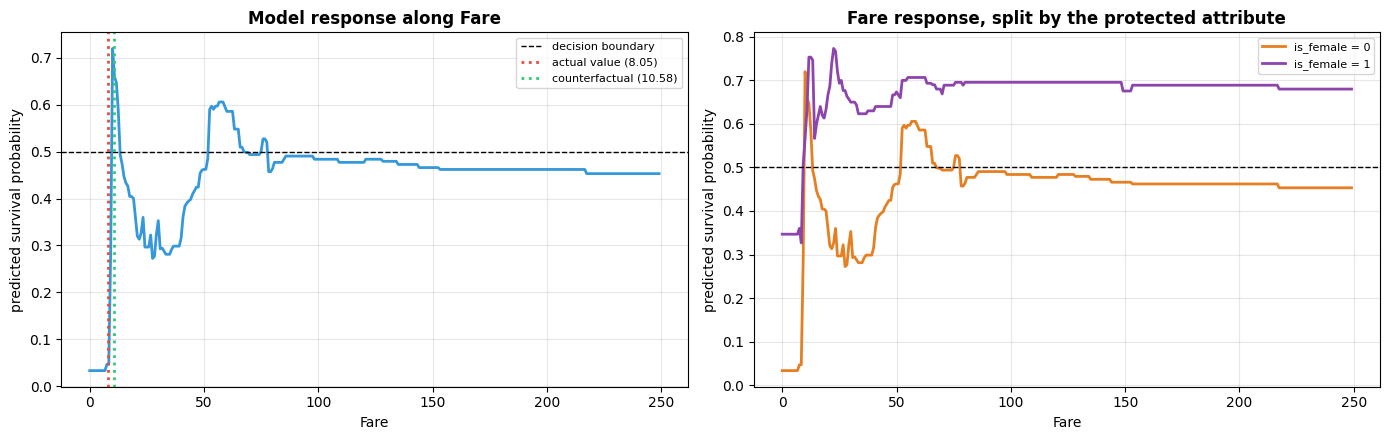

Boundary crossings along this feature: 6
Highest predicted survival probability at Fare = 9.99 (p = 0.72)
Probability at the far end of the range (249.01): p = 0.45

⚠️  THE COUNTERFACTUAL IS VALID AND THE ADVICE IS NONSENSE.
   The model's response to Fare is NOT monotonic. Moving
   further in the 'recommended' direction does not keep helping -
   past the peak it makes things worse again.

   So the sentence 'you would have survived if you had paid a
   little more' is true of THE MODEL and false as guidance. The
   counterfactual found a knife edge in an over-fitted forest, not
   a causal path through the world.

   PRACTICE: never ship a counterfactual without plotting the
   model's response along that feature. Validity is cheap; a stable,
   monotonic region is what makes recourse trustworthy.

RIGHT-HAND PANEL - why single-feature recourse can mislead:
   The two curves are the same passenger with the protected attribute
   set each way. Where they diverge, the 'cost' of recou

In [3]:
# Step 3: Stress-test the counterfactual we just produced
# WHY: a valid counterfactual can still be terrible advice. We check whether the
# model's behaviour along that feature is smooth and monotonic, or a knife edge.
import matplotlib.pyplot as plt

actionable = cf_df[cf_df['actionable']] if len(cf_df) else cf_df
if len(actionable) == 0:
    print("No actionable counterfactual was found, so there is nothing to")
    print("stress-test - which is itself the finding of Part 1.")
else:
    probe_feature = actionable.iloc[0]['feature']
    recommended = actionable.iloc[0]['to']
    print(f"Tracing the model along '{probe_feature}' across its full real range,")
    print(f"instead of stopping at the first value that crosses 0.5.\n")

    # Sweep the feature across the real range present in the data.
    sweep_vals = np.linspace(float(X[probe_feature].min()),
                             float(np.percentile(X[probe_feature], 99)), 300)
    probs = []
    for v in sweep_vals:
        c = passenger.copy(); c[probe_feature] = v
        probs.append(model.predict_proba(pd.DataFrame([c]))[0, 1])
    probs = np.array(probs)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    axes[0].plot(sweep_vals, probs, color='#3498db', linewidth=2)
    axes[0].axhline(0.5, color='black', linestyle='--', linewidth=1,
                    label='decision boundary')
    axes[0].axvline(passenger[probe_feature], color='#e74c3c', linestyle=':',
                    linewidth=2, label=f'actual value ({passenger[probe_feature]:.2f})')
    axes[0].axvline(recommended, color='#2ecc71', linestyle=':', linewidth=2,
                    label=f'counterfactual ({recommended:.2f})')
    axes[0].set_xlabel(probe_feature)
    axes[0].set_ylabel('predicted survival probability')
    axes[0].set_title(f'Model response along {probe_feature}',
                      fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    # Interaction: sweep the same feature separately for each value of the
    # protected attribute, to show single-feature recourse assumes independence.
    for female_val, colour, lbl in [(0.0, '#e67e22', 'is_female = 0'),
                                    (1.0, '#8e44ad', 'is_female = 1')]:
        ps = []
        for v in sweep_vals:
            c = passenger.copy(); c[probe_feature] = v; c['is_female'] = female_val
            ps.append(model.predict_proba(pd.DataFrame([c]))[0, 1])
        axes[1].plot(sweep_vals, ps, color=colour, linewidth=2, label=lbl)
    axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1)
    axes[1].set_xlabel(probe_feature)
    axes[1].set_ylabel('predicted survival probability')
    axes[1].set_title(f'{probe_feature} response, split by the protected attribute',
                      fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Now say what the curve actually shows, computed from it ---
    crossings = int(np.sum(np.diff((probs > 0.5).astype(int)) != 0))
    peak_val = sweep_vals[probs.argmax()]
    print(f"Boundary crossings along this feature: {crossings}")
    print(f"Highest predicted survival probability at "
          f"{probe_feature} = {peak_val:.2f} (p = {probs.max():.2f})")
    print(f"Probability at the far end of the range "
          f"({sweep_vals[-1]:.2f}): p = {probs[-1]:.2f}")

    if crossings > 1 or probs[-1] < probs.max() - 0.1:
        print("\n⚠️  THE COUNTERFACTUAL IS VALID AND THE ADVICE IS NONSENSE.")
        print(f"   The model's response to {probe_feature} is NOT monotonic. Moving")
        print(f"   further in the 'recommended' direction does not keep helping -")
        print(f"   past the peak it makes things worse again.")
        print(f"\n   So the sentence 'you would have survived if you had paid a")
        print(f"   little more' is true of THE MODEL and false as guidance. The")
        print(f"   counterfactual found a knife edge in an over-fitted forest, not")
        print(f"   a causal path through the world.")
        print("\n   PRACTICE: never ship a counterfactual without plotting the")
        print("   model's response along that feature. Validity is cheap; a stable,")
        print("   monotonic region is what makes recourse trustworthy.")
    else:
        print("\n✅ The response is smooth and monotonic in the relevant region, so")
        print("   this counterfactual is defensible as advice - the rarer outcome.")

    print("\nRIGHT-HAND PANEL - why single-feature recourse can mislead:")
    print("   The two curves are the same passenger with the protected attribute")
    print("   set each way. Where they diverge, the 'cost' of recourse depends on")
    print("   the protected attribute: two people would need different amounts of")
    print("   the same change to get the same outcome. That is unequal recourse,")
    print("   and it is invisible to any single-feature counterfactual search.")

print("\n" + "="*70)
print("ASSESSING COUNTERFACTUAL QUALITY - all four criteria")
print("="*70)
print("  - Validity     : does it flip the model's decision?  (Part 1: checked)")
print("  - Proximity    : is the change small?                (Part 1: minimised)")
print("  - Plausibility : is the model's behaviour there sane? (Part 2: TESTED)")
print("  - Actionability: CAN the person change it?           (Part 1: labelled)")
print("\nA counterfactual that passes only the first two is not an explanation -")
print("it is a number that happens to cross a threshold.")

---

## 🚫 When Counterfactual Analysis Hits a Limitation

### The Limitation We Discovered

We've learned counterfactual analysis for "what if" explanations. **But there's still a challenge:**

**How do we ensure accountability and responsibility for AI decisions?**

Counterfactual analysis works well when:
- ✅ We can generate "what if" scenarios
- ✅ We can provide actionable guidance
- ✅ We can explain what would change outcomes

**But transparent AI systems also need:**
- ❌ **Accountability frameworks** (who is responsible?)
- ❌ **Responsibility mechanisms** (how to assign responsibility?)
- ❌ **Audit trails** (how to track decisions?)
- ❌ **Stakeholder accountability** (who answers for outcomes?)

### Why This Is a Problem

When we have explanations but no accountability:
- We may not know who is responsible for AI decisions
- We may not have mechanisms to track and audit decisions
- We may not have clear responsibility structures
- We may not be able to hold anyone accountable

### The Solution: Accountability Frameworks

We need **accountability frameworks** to:
1. Define stakeholder responsibilities
2. Create audit trails
3. Establish responsibility mechanisms
4. Enable accountability for AI decisions

**This is exactly what we'll learn in the next notebook: Accountability Frameworks!**

---

## ➡️ Next Steps

**You've completed this notebook!** Now you understand:
- ✅ How to use SHAP for explanations (Notebook 1)
- ✅ How to use LIME for fast explanations (Notebook 2)
- ✅ How to use counterfactuals for "what if" scenarios (This notebook!)
- ✅ **The limitation**: We need accountability frameworks!

**Next notebook**: `04_accountability_frameworks.ipynb`
- Learn about accountability frameworks
- Understand stakeholder responsibilities
- Create audit trails
- Establish responsibility mechanisms

## 📚 References

1. Wachter, S., Mittelstadt, B. & Russell, C. (2018). *Counterfactual Explanations without Opening the Black Box: Automated Decisions and the GDPR*. Harvard Journal of Law & Technology, 31(2). <https://arxiv.org/abs/1711.00399>
2. Mothilal, R. K., Sharma, A. & Tan, C. (2020). *Explaining Machine Learning Classifiers through Diverse Counterfactual Explanations*. FAT* 2020 (DiCE). <https://arxiv.org/abs/1905.07697>
3. Molnar, C. *Interpretable Machine Learning: A Guide for Making Black Box Models Explainable* (online book). <https://christophm.github.io/interpretable-ml-book/>